In [59]:
from Utils import load_json_files, preprocess_json
import numpy as np
import os
import random

from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA, LatentDirichletAllocation
import matplotlib.pyplot as plt
import pandas as pd

In [3]:
# Matplotlib 한글 깨짐 방지
from matplotlib import rc
rc('font', family='AppleGothic')
plt.rcParams['axes.unicode_minus'] = False

# PreProcessing

In [39]:

folder_path = "../syllabus/json"
json_files = load_json_files(folder_path)  # list[dict]
data = preprocess_json(json_files)  # np.ndarray[str], 원본과 같은 순서 가정
len(data)


1899

In [32]:
sum(1 for d in data if len(d) == 0)

98

In [41]:
data = data[np.array([len(d) > 0 for d in data])]
len(data)

1801

In [43]:

# 원본 인덱스 매핑 배열
orig_idx = np.arange(len(data))

# 1) 사용자 수강 리스트 통합
user_idx = np.array([1])
print([d["교과목명"] for d in json_files[user_idx]])
user_text = " ".join(data[user_idx])
print(user_text)
len(user_text)

['해양학 2']
해양학  oceanography  지구와 해양기원 해양물질순환 해양화학적 과정과 해양퇴적물의 상호관계 해양의 변화와 인간활동과의 연관 해양생물의 종류와 군집 해양생물과 환경적 요인 등에 대한 이해를 통해 해양화학과 해양생물의 기본지식 습득한다  해양에서 발생하는 제반 현상을 이해하기 위해서는 지질해양학 물리해양학 화학해양학 생물해양학의 기초지 식을 갖추어야 하며 강의는 해양에서 발생하는 화학적 생물학적 현상과 물질순환이 지질해양 물리해양과 어떻게 연관성을 가지는지를 이해하는데 중점을 두고  해양의 생명 플랑크톤 조류 해양식물 해양동물 해양군집 해양자원 해양과 환경 중간고사 보강실시 지구의 기원과 해양 해양화학 입문 바닷물의 특성과 성분 해양에서의 물질 순환과 영양염 해양의 탄소순 해양오염 기말고 보강실시 기초교양필수 기말고사 20251006 추석연휴 휴업일 20251008 추석연휴대체휴일 휴업일


450

In [44]:
vectorizer = TfidfVectorizer(
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.85,
    sublinear_tf=True,
    norm="l2",
)
tfidf = vectorizer.fit_transform(data)
tfidf

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 414984 stored elements and shape (1801, 64914)>

# K-Means

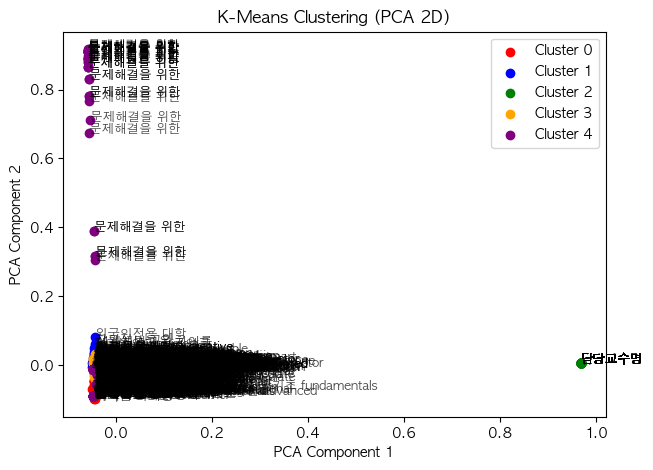

In [45]:

# KMeans 군집화
k = 5
model = KMeans(n_clusters=k, random_state=42)
labels = model.fit_predict(tfidf)

# PCA로 2차원 축
pca = PCA(n_components=2, random_state=42)
reduced = pca.fit_transform(tfidf.toarray())

# 시각화
plt.figure(figsize=(7, 5))
colors = ['red', 'blue', 'green', 'orange', 'purple']

for i in range(k):
    cluster_points = reduced[labels == i]
    plt.scatter(cluster_points[:, 0], cluster_points[:, 1], 
                c=colors[i], label=f'Cluster {i}')

for i, txt in enumerate([" ".join(d.split()[:2]) for d in data]):
    plt.annotate(txt, (reduced[i, 0], reduced[i, 1]), fontsize=9, alpha=0.7)

plt.title("K-Means Clustering (PCA 2D)")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.legend()
plt.show()

- min_df를 비율로 바꾸거나
- features 수를 제한을 두거나
- ngram 없이 나누고, 명사/동사/형용사 추출해서 원형만 남기기

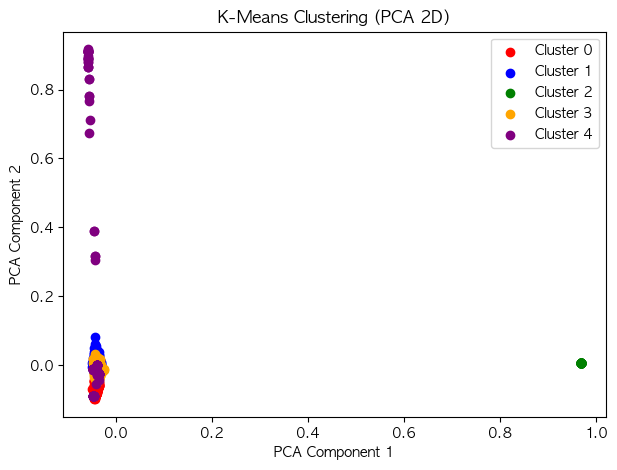

In [46]:

# KMeans 군집화
k = 5
model = KMeans(n_clusters=k, random_state=42)
labels = model.fit_predict(tfidf)

# PCA로 2차원 축
pca = PCA(n_components=2, random_state=42)
reduced = pca.fit_transform(tfidf.toarray())

# 시각화
plt.figure(figsize=(7, 5))
colors = ['red', 'blue', 'green', 'orange', 'purple']

for i in range(k):
    cluster_points = reduced[labels == i]
    plt.scatter(cluster_points[:, 0], cluster_points[:, 1], 
                c=colors[i], label=f'Cluster {i}')

# for i, txt in enumerate([" ".join(d.split()[:2]) for d in data]):
#     plt.annotate(txt, (reduced[i, 0], reduced[i, 1]), fontsize=9, alpha=0.7)

plt.title("K-Means Clustering (PCA 2D)")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.legend()
plt.show()

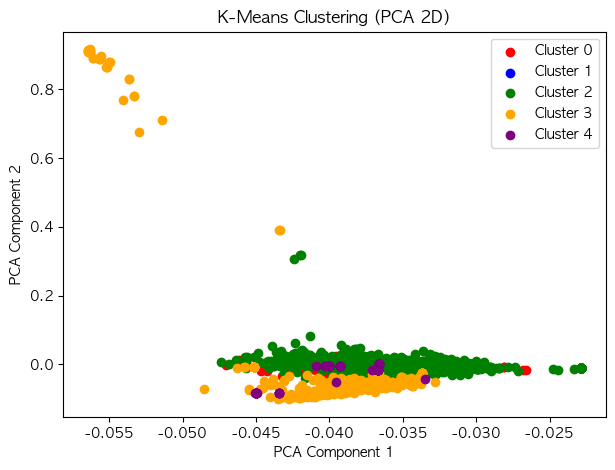

In [14]:

# KMeans 군집화
k = 5
model = KMeans(n_clusters=k, random_state=42)
labels = model.fit_predict(tfidf)

# PCA로 2차원 축
pca = PCA(n_components=2, random_state=42)
reduced = pca.fit_transform(tfidf.toarray())

filter_condition = reduced[:, 0] < 0.5
filtered_reduced = reduced[filter_condition]
filtered_labels = labels[filter_condition]

# 시각화
plt.figure(figsize=(7, 5))
colors = ['red', 'blue', 'green', 'orange', 'purple']

for i in range(k):
    cluster_points = filtered_reduced[filtered_labels == i]
    plt.scatter(cluster_points[:, 0], cluster_points[:, 1], 
                c=colors[i], label=f'Cluster {i}')

# for i, txt in enumerate([" ".join(d.split()[:2]) for d in data]):
#     plt.annotate(txt, (reduced[i, 0], reduced[i, 1]), fontsize=9, alpha=0.7)

plt.title("K-Means Clustering (PCA 2D)")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.legend()
plt.show()

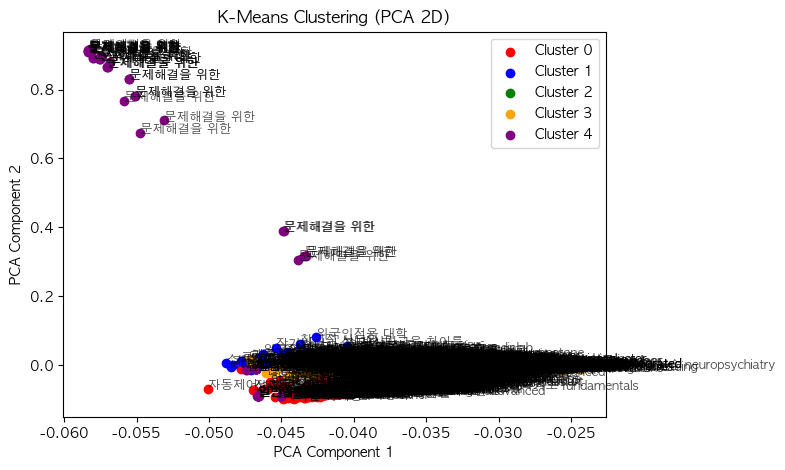

In [48]:

# KMeans 군집화
k = 5
model = KMeans(n_clusters=k, random_state=42)
labels = model.fit_predict(tfidf)

# PCA로 2차원 축
pca = PCA(n_components=2, random_state=42)
reduced = pca.fit_transform(tfidf.toarray())

filter_condition = reduced[:, 0] < 0.5
filtered_reduced = reduced[filter_condition]
filtered_labels = labels[filter_condition]

# 시각화
plt.figure(figsize=(7, 5))
colors = ['red', 'blue', 'green', 'orange', 'purple']

for i in range(k):
    cluster_points = filtered_reduced[filtered_labels == i]
    plt.scatter(cluster_points[:, 0], cluster_points[:, 1], 
                c=colors[i], label=f'Cluster {i}')

for i, txt in enumerate([" ".join(d.split()[:2]) for d in data]):
    plt.annotate(txt, (reduced[i, 0], reduced[i, 1]), fontsize=9, alpha=0.7)

plt.title("K-Means Clustering (PCA 2D)")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.legend()
plt.show()

IndexError: index 1723 is out of bounds for axis 0 with size 1699

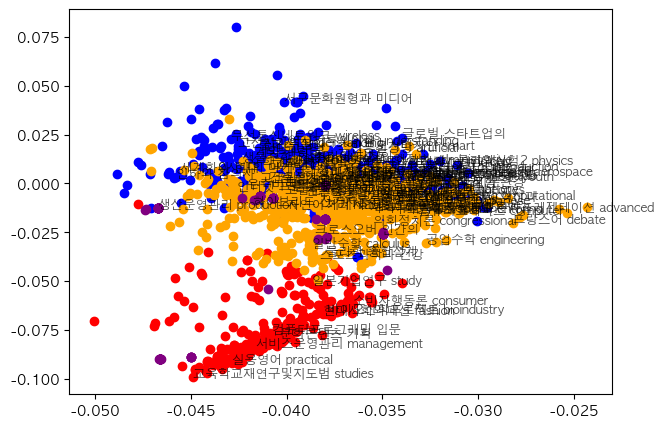

In [64]:

# KMeans 군집화
k = 5
model = KMeans(n_clusters=k, random_state=42)
labels = model.fit_predict(tfidf)

# PCA로 2차원 축
pca = PCA(n_components=2, random_state=42)
reduced = pca.fit_transform(tfidf.toarray())

filter_condition = reduced[:, 0] < 0.5
reduced = reduced[filter_condition]
labels = labels[filter_condition]


filter_condition = reduced[:, 1] < 0.2
reduced = reduced[filter_condition]
labels = labels[filter_condition]

# 시각화
plt.figure(figsize=(7, 5))
colors = ['red', 'blue', 'green', 'orange', 'purple']

for i in range(k):
    cluster_points = reduced[labels == i]
    plt.scatter(cluster_points[:, 0], cluster_points[:, 1], 
                c=colors[i], label=f'Cluster {i}')

for i, txt in enumerate([" ".join(d.split()[:2]) for d in data]):
    if random.random() < 0.05:
        plt.annotate(txt, (reduced[i, 0], reduced[i, 1]), fontsize=9, alpha=0.7)

plt.title("K-Means Clustering (PCA 2D)")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.legend()
plt.show()

In [54]:

# PCA로 2차원 축
pca = PCA(n_components=2, random_state=42)
reduced = pca.fit_transform(tfidf.toarray())
df = pd.DataFrame(reduced, columns=['PCA1', 'PCA2'])
df

,PCA1,PCA2
0,-0.039741,0.015416
1,-0.031058,-0.014530
2,-0.028170,-0.020113
3,-0.037102,0.003545
4,-0.042356,-0.091331
...,...,...
1796,-0.035282,0.009317
1797,-0.047108,-0.012731
1798,0.968572,0.006069
1799,-0.036359,-0.002071


In [56]:
df.describe()

,PCA1,PCA2
count,1.801000e+03,1.801000e+03
mean,-9.123432e-17,-6.472705e-16
std,1.934249e-01,1.141970e-01
min,-5.837562e-02,-9.900144e-02
25%,-4.070439e-02,-1.809292e-02
50%,-3.807838e-02,-6.502003e-03
75%,-3.536850e-02,3.874087e-03
max,9.685716e-01,9.171237e-01


array([[<Axes: title={'center': 'PCA1'}>,
        <Axes: title={'center': 'PCA2'}>]], dtype=object)

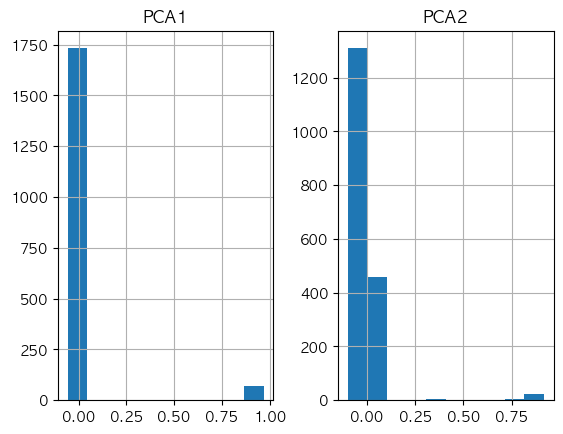

In [55]:
df.hist()

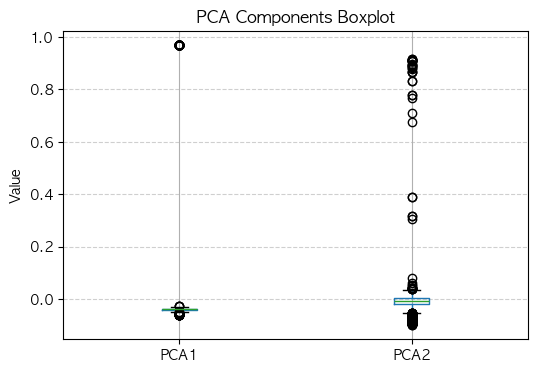

In [57]:
plt.figure(figsize=(6, 4))
df.boxplot(column=['PCA1', 'PCA2'])
plt.title("PCA Components Boxplot")
plt.ylabel("Value")
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.show()

In [47]:
for i in range(k):
    print(f"Cluster {i} Courses:")
    for course in data[labels == i][:20]:
        print(f" - {course}")

Cluster 0 Courses:
 - 식스 시그마 품질관리  six sigma quality management  course objective contribution learning goal assessment method to help students to derive solutions from real cases based on their reasoning and analysis 30 critical thinking class discuss of cases to make students understand theoretical meaning of six sigma and how to implement six sigma quality management in real setting 70 functional knowledge in class exams  over the past fifteen years us firms have learned the painful lesson that the neglect of quality management can be extremely hazardous to the health of the organization foreign firms have demonstrated that quality can be an effective competitive weapon in conjunction with well conceived marketing and financial plans this course is designed to address the key issues of productivity and quality through the course you will gain the ability to manage an organization to attain higher productivity and quality  differing perspectives on quality to explore the quality conc

## 한국어로만

In [65]:
data

array(['웰니스를 위한 걷기와 달리기  walking and running for wellness  걷기와 달리기와 관련된 다양한 주제를 분석하고 자신의 생각을 명확하게 정리하여 타인에게 전달할 있는 능력을 기를 있다 학생들은 달리기와 걷기와 관련된 지식을 이론적으로 이해하고 이를 실제 훈련과 운동 계획에 적용하는 능력을 기를 있다 스마트 기기나 앱을 활용하여 운동 데이터를 분석하고 이를 토대로 자신에게 맞는 훈련 방법을 찾아낼 있다 학생들은 활동을 통해 타인의 상태와 의견을 존중하고 협력하는 방법을 습득할수 있다  수업은 걷기와 달리기를 통해 신체적 건강뿐만 아니라 정신적 건강까지 관리할 있는 기회를 제공하는 교양체육 수업이다 현대 사회에서 건강 관리는 신체적인 측면뿐 아니라 정신적 사회적 요소까지 종합적으로 고려해야하며 이를 위한 가장 기본적이고 자연스러운 방법이 걷기와 달리기이다 걷기와 달리기는 시간적 제약이나 경제적부담 없이 쉽게 실천할 있는 운동으로 심혈관 건강을 개선하고 스트레스를 해소하며 자신감을 향상시키는 데효과적이다 또한 단체로 함께 운동할 있어 사회적 교류와 협력 소통 능력을 기를 있는 기회를 제공한다  walking running trend 걷기와 달리기를 위한 좋은 준비운동 정신건강 증진을 위한 걷기와 달리기 걷기 운동의 올바른 자세와 동작걷기 운동의 기본 자세 안정된 걷기 단계별 걷기 프로그램과 파워워킹 셀프 트레이닝 프로그램 설계하기 달리기 기본 10단계 나에게 가장 알맞은 주법 찾기 좋은 달리기 자세 중간평가 신체유형별 러닝 훈련법 탄성 메커니즘을 활용한 달리기 걷기와 달리기의 지속을 위한 심리 트레이닝 방법 walking running으로 인한 부상을 예방하고 완화하는 방법 트레일 러닝 오르막의 기술 내리막의 기술 러닝 크루 만들고 운영하기 기말평가 보강실시 기초교양필수 기말고사 20251006 추석연휴 보강주간',
       '해양학  oceanography  지구와 해양기원 해양물질순환 해양화학적 과정과 해양퇴적물의 상호

In [ ]:
from konlpy.tag import Okt

# 형태소 분석기
okt = Okt()

def tokenize_korean(text):
    tokens = okt.pos(text, stem=True)
    return [word for word, pos in tokens if pos in ['Noun', 'Adjective', 'Verb']]

# 샘플 데이터
docs = [
    "오늘 날씨가 정말 좋네요",
    "오늘은 기분이 좋지 않아요",
    "내일은 비가 올 것 같아요",
    "비 오는 날씨가 싫어요",
    "맑은 하늘이 정말 좋아요",
]

for doc in docs:
    print(tokenize_korean(doc))

['오늘', '날씨', '정말', '좋다']
['오늘', '기분', '좋다', '않다']
['내일', '비', '오다', '것', '같다']
['비', '오다', '날씨', '싫다']
['맑은', '하늘', '정말', '좋다']


In [68]:
hard_words = np.array([' '.join(tokenize_korean(d)) for d in data])
hard_words

array(['웰니스 위 걷기 달리기 걷기 달리기 관련 되다 다양하다 주제 분석 자신 생각 명확하다 정리 하다 타인 전달 하다 있다 능력 기르다 있다 학생 달리기 걷기 관련 되다 지식 이론 이해 이르다 실제 훈련 운동 계획 적용 하다 능력 기르다 있다 스마트 기기 앱 활용 하다 운동 데이터 분석 이르다 토대 자신 맞다 훈련 방법 찾아내다 있다 학생 활동 통해 타인 상태 의견 존중 협력 하다 방법 습득 하다 있다 수업 걷기 달리기 통해 신체 건강 아니다 정신 건강 관리 하다 있다 기회 제공 하다 교양 체육 수업 현대 사회 건강 관리 신체 측면 아니다 정신 사회 요소 종합 고려 하다 이르다 위 가장 기본 자연스럽다 방법 걷기 달리기 걷기 달리기 시간 제약 경제 부담 쉬다 실천 하다 있다 운동 심 혈관 건강 개선 스트레스 해소 하다 자신감 향상 시키다 데 효과 또한 단체 운동 하다 있다 사회 교류 협력 소통 능력 기르다 있다 기회 제공 걷기 달리기 위 좋다 준비운동 정신건강 증진 위 걷기 달리기 걷기 운동 올바르다 자세 동작 걷기 운동 기본 자세 안정 되다 걷기 단계 별 걷기 프로그램 파워워킹 셀프 트레이닝 프로그램 설계 하다 달리기 기본 단계 나 가장 알맞다 주법 찾기 좋다 달리기 자세 중간 평가 신체 유형 별 러닝 훈련 법 탄성 메커니즘 활용 달리기 걷기 달리기 지속 위 심리 트레이닝 방법 인하다 부상 예방 완화 하다 방법 트레일 러닝 오르막 기술 내리막 기술 러닝 크루 만들다 운영 하다 말 평가 보강 실시 기초 교양 필수 기말고사 추석 연휴 보강 주간',
       '해양학 지구 해양 기원 해양 물질 순환 해양 학적 과정 해양 퇴적물 상호 관계 해양 변화 인간 활동 연관 해양 생물 종류 군집 해양 생물 환경 요인 등 대한 이해 통해 해양 학과 해양 생물 기본 지식 습득 하다 해양 발생 하다 제반 현상 이해 하다 위 하다 지질 해양학 물리해양학 화학 해양학 생물 해양학 기초 식 갖추다 하다 강의 해양 발생 하다 화학 생물학 현상 물질 순환 지질 해양 물리 해양

In [69]:
vectorizer = TfidfVectorizer(
    # ngram_range=(1, 2),
    min_df=2,
    max_df=0.85,
    max_features=1000,
    sublinear_tf=True,
    norm="l2",
)
tfidf_hard = vectorizer.fit_transform(hard_words)
tfidf_hard

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 117864 stored elements and shape (1801, 1000)>

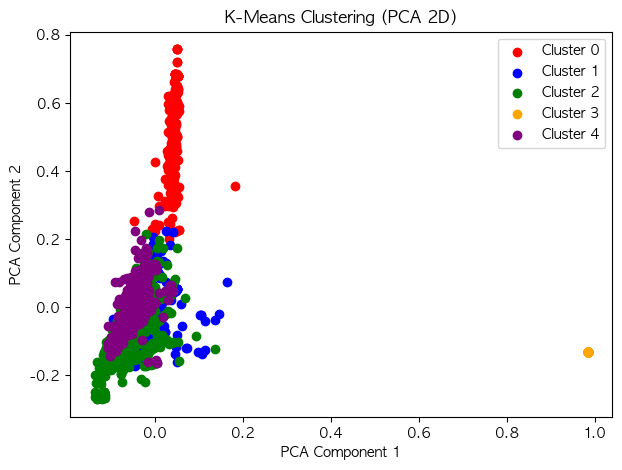

In [ ]:

# KMeans 군집화
k = 5
model = KMeans(n_clusters=k, random_state=42)
labels = model.fit_predict(tfidf_hard)

# PCA로 2차원 축
pca = PCA(n_components=2, random_state=42)
reduced = pca.fit_transform(tfidf_hard.toarray())

# 시각화
plt.figure(figsize=(7, 5))
colors = ['red', 'blue', 'green', 'orange', 'purple']

for i in range(k):
    cluster_points = reduced[labels == i]
    plt.scatter(cluster_points[:, 0], cluster_points[:, 1], 
                c=colors[i], label=f'Cluster {i}')

# for i, txt in enumerate([" ".join(d.split()[:2]) for d in data]):
#     plt.annotate(txt, (reduced[i, 0], reduced[i, 1]), fontsize=9, alpha=0.7)

plt.title("K-Means Clustering (PCA 2D)")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.legend()
plt.show()

IndexError: index 1732 is out of bounds for axis 0 with size 1732

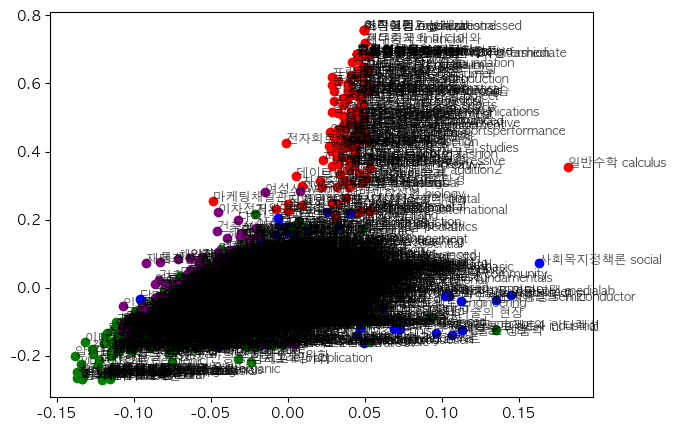

In [75]:

# KMeans 군집화
k = 5
model = KMeans(n_clusters=k, random_state=42)
labels = model.fit_predict(tfidf_hard)

# PCA로 2차원 축
pca = PCA(n_components=2, random_state=42)
reduced = pca.fit_transform(tfidf_hard.toarray())

filter_condition = reduced[:, 0] < 0.5
reduced = reduced[filter_condition]
labels = labels[filter_condition]

# 시각화
plt.figure(figsize=(7, 5))
colors = ['red', 'blue', 'green', 'orange', 'purple']

for i in range(k):
    cluster_points = reduced[labels == i]
    plt.scatter(cluster_points[:, 0], cluster_points[:, 1], 
                c=colors[i], label=f'Cluster {i}')

for i, txt in enumerate([" ".join(d.split()[:2]) for d in data]):
    plt.annotate(txt, (reduced[i, 0], reduced[i, 1]), fontsize=9, alpha=0.7)

plt.title("K-Means Clustering (PCA 2D)")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.legend()
plt.show()

In [71]:
for i in range(k):
    print(f"Cluster {i} Courses:")
    for course in data[labels == i][:20]:
        print(f" - {course}")

Cluster 0 Courses:
 - 프랑스어  debate in french  les etudiants qui auront suivi le cours seront prepares de maniere intensive aux pratiques expression orale consistant repondre des questions concernant un travail presente oralement dans la classe ou de participer de maniere active une discussion de groupe cette formation devrait les aider dans la poursuite de leurs etudes dans un cycle superieur en particulier dans hypothese ou ils integreraient un etablissement etranger ainsi que dans leur vie professionnelle les preentations et reunions de travail etant frequentes en entreprise  ce cours adresse des etudiants de niveau moyen ou avance qui souhaitent habituer et se perfectionner dans les techniques de discussion et de debat sur un sujet donne et avec un ou plusieurs interlocuteurs deux possibilites seront proposees comme activites de classe presenter oralement un court expose et repondre aux questions posees par les etudiants ou participer une discussion de groupe au cours de laquelle ch

# LDA

In [16]:
count_vectorizer = CountVectorizer(
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.85,
    # max_features=1000,
)
count_vec = count_vectorizer.fit_transform(data)
count_vec.shape

(1899, 64914)

In [20]:
lda = LatentDirichletAllocation(n_components=5, random_state=42)
lda_topics = lda.fit_transform(count_vec)

In [21]:
lda.components_.shape, lda.components_[0]

((5, 64914),
 array([3.90536806, 1.22299847, 0.20000029, ..., 0.97215135, 0.20000006,
        0.20000006], shape=(64914,)))

In [22]:
def display_topics(model, feature_names, no_top_words):
    for topic_idx, topic in enumerate(model.components_):
        print(f"Topic {topic_idx}:")
        print(" ".join([feature_names[i]
                        for i in topic.argsort()[:-no_top_words - 1:-1]]))

feature_names = count_vectorizer.get_feature_names_out()
display_topics(lda, feature_names, 10)

Topic 0:
and of the to in for course will students exam
Topic 1:
대한 통해 대해 있는 분석 위한 실험 다양한 있다 중간고사
Topic 2:
따른 통해 쓰기 대한 글쓰기 pbl 발표 연습 구성 있는
Topic 3:
발표 있다 설계 대한 위한 분석 소개 제출 작성 통해
Topic 4:
대한 있다 활동 화학 평형 분반 분반 활동 반응 대해 중간고사
